# **실습04 : CNN 모델링 실습**

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32) 6만장
    * 10가지 클래스로 분류하기 위한 모델 생성

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [4]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [5]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0                  # 전체 데이터셋의 크기
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [6]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [7]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [8]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [9]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [10]:
train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

In [11]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

* y(target)의 클래스

In [12]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* 데이터 1건

In [13]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

* 데이터 이미지 확인

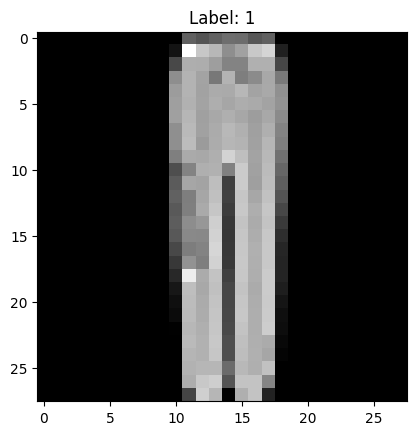

In [15]:
n =
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## **2.데이터 준비**

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [17]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [18]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옵니다.
    * 스케일링 안된 데이터
    * 5000, 28, 28 : 3차원 데이터셋
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 4차원 변환 : 5000, 1, 28, 28

In [26]:
X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [27]:
X_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

#### 1) 스케일링

In [28]:
X_val = X_val / 255
X_test = X_test/ 255

#### 2) 3차원 데이터셋 --> 4차원 데이터셋

In [29]:
X_val = X_val.view(5000, 1, 28, 28)
X_test = X_test.view(5000, 1, 28, 28)

print(X_val.shape, X_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## **3.모델링**

### (1) 모델 선언

In [30]:
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1,8, kernel_size=3, padding=1), # input = 1*28*28, output = 8*28*28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(8*14*14, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# 토치 모델 요약
summary(model1, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
           Flatten-4                 [-1, 1568]               0
            Linear-5                   [-1, 64]         100,416
              ReLU-6                   [-1, 64]               0
            Linear-7                   [-1, 10]             650
Total params: 101,146
Trainable params: 101,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.39
Estimated Total Size (MB): 0.51
----------------------------------------------------------------


In [31]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

### (2) 학습

In [32]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.5331, val loss : 0.3922
Epoch 2, train loss : 0.3509, val loss : 0.3573
Epoch 3, train loss : 0.3108, val loss : 0.3441
Epoch 4, train loss : 0.2840, val loss : 0.3275
Epoch 5, train loss : 0.2631, val loss : 0.3173
Epoch 6, train loss : 0.2461, val loss : 0.3096
Epoch 7, train loss : 0.2318, val loss : 0.3015
Epoch 8, train loss : 0.2194, val loss : 0.3001
Epoch 9, train loss : 0.2080, val loss : 0.2972
Epoch 10, train loss : 0.1975, val loss : 0.2959
Epoch 11, train loss : 0.1876, val loss : 0.2930
Epoch 12, train loss : 0.1786, val loss : 0.2948
Epoch 13, train loss : 0.1700, val loss : 0.2963
Epoch 14, train loss : 0.1617, val loss : 0.2965
Epoch 15, train loss : 0.1546, val loss : 0.2991
Epoch 16, train loss : 0.1476, val loss : 0.3016
Epoch 17, train loss : 0.1403, val loss : 0.3097
Epoch 18, train loss : 0.1337, val loss : 0.3161
Epoch 19, train loss : 0.1275, val loss : 0.3249
Epoch 20, train loss : 0.1217, val loss : 0.3321


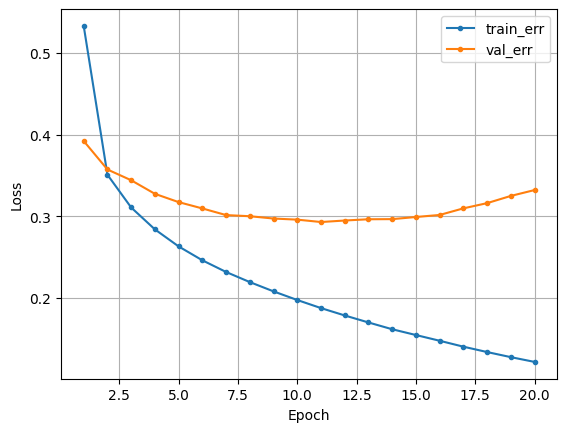

In [33]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [35]:
_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
pred[:5]

tensor([[  1.6026, -24.3117,  10.8921,  -6.4842,   1.5037, -18.6784,   3.7303,
         -33.2497, -14.1078, -36.4825],
        [  4.9728,  -8.7772,  -3.8126,  12.0454,  -3.4530, -21.0435,  -2.6660,
         -11.2532,  -7.9273, -33.6378],
        [ -1.2366, -13.9799,  -4.8629, -10.5470,   3.1299, -18.0625,   1.8471,
         -12.6350,  -4.4820,  -9.0986],
        [ -3.6055, -27.2200,   3.9163, -12.0803,  13.2221, -23.6674,   0.7310,
         -31.5479, -13.7486, -17.1840],
        [ -6.9511, -11.4206,  -0.5499,  -6.1056,   4.9677, -11.6731,   6.1412,
         -22.4755,  -8.4729, -17.6225]], device='cuda:0')

In [36]:
pred_prob = nn.functional.softmax(pred, dim=1)
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)
pred_class[:10]

array([2, 3, 4, 4, 6, 3, 3, 9, 4, 7])

In [37]:
cm = confusion_matrix(y_test.cpu().numpy(), pred_class)
cm

array([[436,   0,  11,  11,   2,   1,  30,   0,   2,   0],
       [  2, 498,   1,   9,   2,   0,   7,   0,   0,   0],
       [ 13,   1, 409,   3,  31,   0,  21,   0,   1,   0],
       [  6,   1,   4, 470,   8,   0,  11,   0,   0,   0],
       [  1,   0,  32,  12, 396,   0,  38,   0,   0,   0],
       [  0,   0,   0,   1,   0, 491,   0,  13,   1,   9],
       [ 67,   0,  23,  19,  27,   0, 376,   0,   6,   0],
       [  0,   0,   0,   0,   0,   9,   0, 469,   0,  22],
       [  2,   0,   1,   2,   1,   0,   3,   1, 464,   0],
       [  2,   0,   0,   0,   0,   5,   0,  13,   0, 503]])

In [38]:
print(accuracy_score(y_test.numpy(), pred_class))
print('-' * 100)
print(classification_report(y_test.numpy(), pred_class))

0.9024
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       493
           1       1.00      0.96      0.98       519
           2       0.85      0.85      0.85       479
           3       0.89      0.94      0.92       500
           4       0.85      0.83      0.84       479
           5       0.97      0.95      0.96       515
           6       0.77      0.73      0.75       518
           7       0.95      0.94      0.94       500
           8       0.98      0.98      0.98       474
           9       0.94      0.96      0.95       523

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



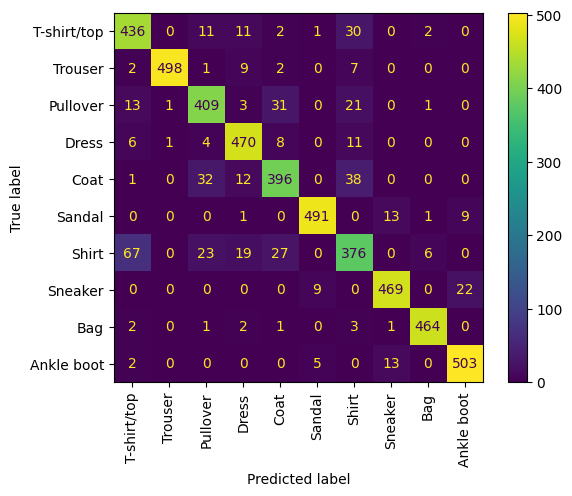

In [39]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

In [41]:
import random as rd

In [42]:
idx = (y_test.numpy() != pred_class)
X_test_wr = X_test[idx]
y_test_wr = y_test[idx]
pred_wr = pred_class[idx]

X_test_wr = X_test_wr.reshape(-1, 28, 28)
print(X_test_wr.shape)

torch.Size([488, 28, 28])


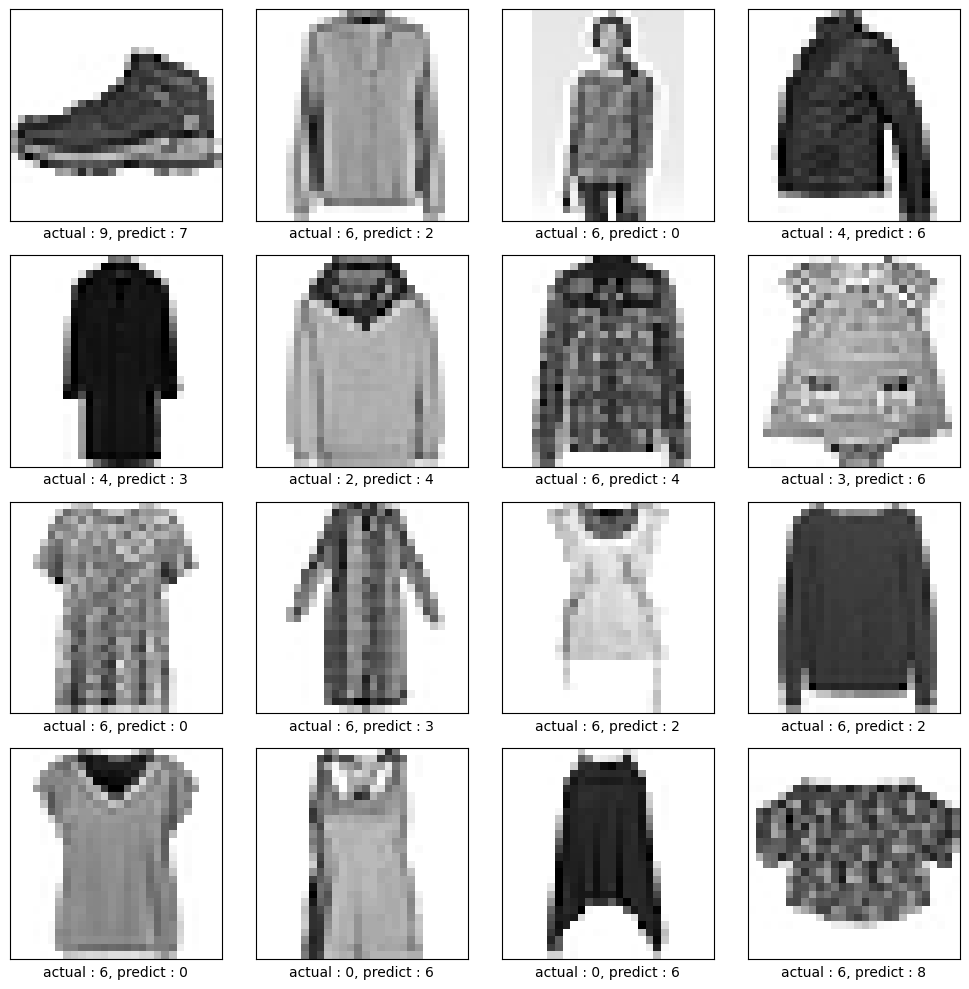

In [43]:
idx = rd.sample(range(X_test_wr.shape[0]), min(16, X_test_wr.shape[0]))
X_temp = X_test_wr[idx]
y_temp = y_test_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10, 10))
for i in range(len(idx)):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f"actual : {y_temp[i]}, predict : {p_temp[i]}")
plt.tight_layout()
plt.show()